# U.S. Earthquake Analysis (2015–2025)

CMSC 320 – Introduction to Data Science, Spring 2026

Leul Belay, Nathan Zhao, Zoie Luka, Joshua Wong

## 1. Contributions

| Name | Sections | Contribution |
| --- | --- | --- |
| Leul Belay | A, D, E | Project idea, ML model design and training, test data analysis |
| Nathan Zhao | B, C, F | Data curation and preprocessing, exploratory data analysis, visualizations |
| Zoie Luka | F, G | Visualizations, result analysis, final tutorial report |
| Joshua Wong | C, F | Exploratory analysis, hypothesis testing, visualizations |

## 2. Introduction

Earthquakes represent one of nature's most significant dangers due to their unpredictability and potential for destruction based on their geolocation, depth, and strength of the stress that created them. While not all earthquakes will create significant hazards, analyzing additional records for multiple earthquakes can provide insight into the locations where larger magnitude earthquakes are likely to occur and what characteristics may contribute to their severity. 

Our project will involve analyzing information on earthquakes taken from the US Geological Survey (also referred to as USGS). The dataset will include data from earthquakes that occurred between 2015-2025 within the contiguous United States that had magnitudes of 3.0 or greater. The number of earthquakes available creates a dataset large enough to identify trends while also focusing on the types of earthquakes that could represent potential hazards. 

The purpose of the project is to walk through the data science process using earthquake data. This is done by initially collecting and cleaning the dataset, then using summary statistics as well as different forms of data visualizations to examine and analyze the data, and lastly using machine learning techniques to determine if the recorded characteristics of earthquakes can help predict whether or not an earthquake will be classified as significant based on magnitude.

In doing this project, we hope to answer the following questions:
1. How is earthquake magnitude distributed across the United States?
2. Do earthquakes have different magnitude distributions by season?
3. Is there a relationship between earthquake features and either magnitude or error?
4. Can features such as latitude, longitude, depth, year, month, hour, and day of week be used to predict whether an earthquake will be classified as significant?

In the machine learning section, we define an earthquake with a magnitude of 4.5 or higher as significant. Earthquakes with magnitudes below 4.5 are still important; however, 4.5 is the cutoff we use for classification because it gives us a binary answer for whether or not an earthquake is significant.

Earthquake patterns are critical for public safety, hazard planning, and understanding the impact of seismic activity. Our primary objective is not to predict the occurrence of future earthquakes, but to use data to analyze historical seismic activity and determine whether any trends or patterns exist.


## 3. Data Curation

The USGS ANSS Comprehensive Earthquake Catalog (ComCat)
 was used in this study and queried through the FDSN Event API. It contains earthquake events recorded by the United States Geological Survey. Each row represents a single seismic event, and the columns contain information about that event, such as timestamp, latitude and longitude coordinates, depth, magnitude, event type, and measurement error.

The data for this project includes earthquakes with a minimum magnitude of M3.0 that occurred in the contiguous United States from 2015 through 2025. Using only earthquakes with a magnitude of M3.0 or higher helps make the data focused enough for analysis while still keeping it large enough to detect patterns and build machine learning models.

### Query parameters

| Parameter | Value |
| --- | --- |
| starttime | 2015-01-01 |
| endtime | 2025-12-31 |
| minmagnitude | 3.0 |
| latitude range | 24.40° to 49.38° |
| longitude range | −124.85° to −66.89° |
| format | CSV |

The latitude and longitude limits were used to keep the data within the contiguous United States. The data was downloaded as a CSV file, which makes it easy to load into pandas and organize as a DataFrame.

### Sources

- [USGS Earthquake Catalog](https://earthquake.usgs.gov/earthquakes/search/)
- [ComCat Documentation](https://earthquake.usgs.gov/data/comcat/)
- [FDSN Event API](https://earthquake.usgs.gov/fdsnws/event/1/)
- [USGS CSV Column Documentation](https://earthquake.usgs.gov/earthquakes/feed/v1.0/csv.php)

### Loading the data

First, we import the libraries needed for this part of the project. Pandas is used to load and organize the dataset, while NumPy, Matplotlib, and SciPy are used later for analysis, plots, and statistical testing.

In [10]:
# All libraries needed for data exploration
import pandas as pd
from datetime import datetime
import string
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

Next, we load the CSV file into a pandas DataFrame. This lets us work with the earthquake records in a table format.

In [11]:
# The dataframe that contains the earthquake data
df = pd.read_csv("query.csv")
df.head(5)

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2025-12-29T00:41:14.360Z,40.547000,-120.700833,6.7800,4.70,mw,30.0,61.0,0.08067,0.1400,nc,nc75287861,2026-02-17T23:14:25.095Z,"15 km NNW of Susanville, CA",earthquake,0.250000,0.72000,NaN,95.0,reviewed,nc,nc
1,2025-12-28T19:02:07.730Z,37.943833,-118.679667,14.0100,3.29,ml,72.0,59.0,0.23770,0.1300,nc,nc75287626,2026-01-19T21:20:01.040Z,"39 km E of Lee Vining, CA",earthquake,0.200000,0.66000,0.186000,36.0,reviewed,nc,nc
2,2025-12-28T17:47:09.990Z,37.663333,-84.457500,6.8500,3.09,md,18.0,55.0,0.37240,0.3200,se,se60616506,2026-02-12T20:26:14.260Z,"11 km ENE of Lancaster, Kentucky",earthquake,0.410000,2.29000,0.022049,12.0,reviewed,se,se
3,2025-12-27T15:20:28.858Z,39.160600,-119.047400,5.0000,3.65,mw,43.0,74.0,0.23100,0.1321,nn,nn00908938,2026-01-20T22:57:55.205Z,"21 km NNE of Yerington, Nevada",earthquake,NaN,1.16400,NaN,NaN,reviewed,nn,nn
4,2025-12-27T01:00:26.055Z,31.964000,-103.122000,8.8135,3.30,ml,37.0,58.0,0.20000,0.2000,tx,tx2025zkxkwi,2026-01-19T23:03:44.040Z,"12 km NNW of Kermit, Texas",earthquake,0.961404,2.87351,0.200000,53.0,reviewed,tx,tx


Before cleaning the data, we check the size of the dataset so we know how many rows and columns we are starting with.

In [12]:
# To display the number of rows and columns
num_rows = len(df)
num_cols = len(df.columns)

print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_cols}")

Number of rows: 12899
Number of columns: 22


We also check the data types for each column. This is important because columns like time should eventually be treated as dates instead of plain text.

In [13]:
# To get all the column names and their types
df.dtypes

time                   str
latitude           float64
longitude          float64
depth              float64
mag                float64
magType                str
nst                float64
gap                float64
dmin               float64
rms                float64
net                    str
id                     str
updated                str
place                  str
type                   str
horizontalError    float64
depthError         float64
magError           float64
magNst             float64
status                 str
locationSource         str
magSource              str
dtype: object

Then, we check how much non-missing data is available in each column. This helps us decide which columns need to be cleaned before analysis.

In [14]:
# To see if there's any missing data in the dataset
total_non_mising = df.count()
total_non_mising

time               12899
latitude           12899
longitude          12899
depth              12899
mag                12899
magType            12898
nst                 7964
gap                12746
dmin               10926
rms                12896
net                12899
id                 12899
updated            12899
place              12899
type               12899
horizontalError    11548
depthError         12896
magError            9845
magNst             11208
status             12899
locationSource     12899
magSource          12899
dtype: int64

We also check duplicates in each column. This does not mean every duplicate is bad, because many columns should naturally repeat values, but it gives us a better idea of what the data looks like.

In [15]:
# To see if columns that should not have a duplicate has a duplicate value
for col in df.columns:
  print(f"Column: {col}, Duplicates: {df[col].duplicated().sum()}")

Column: time, Duplicates: 0
Column: latitude, Duplicates: 1502
Column: longitude, Duplicates: 1285
Column: depth, Duplicates: 8883
Column: mag, Duplicates: 12657
Column: magType, Duplicates: 12885
Column: nst, Duplicates: 12674
Column: gap, Duplicates: 11557
Column: dmin, Duplicates: 7391
Column: rms, Duplicates: 11960
Column: net, Duplicates: 12886
Column: id, Duplicates: 0
Column: updated, Duplicates: 2929
Column: place, Duplicates: 6750
Column: type, Duplicates: 12891
Column: horizontalError, Duplicates: 11249
Column: depthError, Duplicates: 10968
Column: magError, Duplicates: 12356
Column: magNst, Duplicates: 12546
Column: status, Duplicates: 12896
Column: locationSource, Duplicates: 12881
Column: magSource, Duplicates: 12878


### Cleaning and preparing the data

The first cleaning step is converting the `time` and `updated` columns into datetime format. This makes it possible to pull out useful time features like year, month, day, and hour.

In [16]:
# To fix the time and updated columns to represent in datetime format
df["time"] = pd.to_datetime(df["time"], errors="coerce")
df["updated"] = pd.to_datetime(df["updated"], errors="coerce")

df.head(5)

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2025-12-29 00:41:14.360000+00:00,40.547000,-120.700833,6.7800,4.70,mw,30.0,61.0,0.08067,0.1400,nc,nc75287861,2026-02-17 23:14:25.095000+00:00,"15 km NNW of Susanville, CA",earthquake,0.250000,0.72000,NaN,95.0,reviewed,nc,nc
1,2025-12-28 19:02:07.730000+00:00,37.943833,-118.679667,14.0100,3.29,ml,72.0,59.0,0.23770,0.1300,nc,nc75287626,2026-01-19 21:20:01.040000+00:00,"39 km E of Lee Vining, CA",earthquake,0.200000,0.66000,0.186000,36.0,reviewed,nc,nc
2,2025-12-28 17:47:09.990000+00:00,37.663333,-84.457500,6.8500,3.09,md,18.0,55.0,0.37240,0.3200,se,se60616506,2026-02-12 20:26:14.260000+00:00,"11 km ENE of Lancaster, Kentucky",earthquake,0.410000,2.29000,0.022049,12.0,reviewed,se,se
3,2025-12-27 15:20:28.858000+00:00,39.160600,-119.047400,5.0000,3.65,mw,43.0,74.0,0.23100,0.1321,nn,nn00908938,2026-01-20 22:57:55.205000+00:00,"21 km NNE of Yerington, Nevada",earthquake,NaN,1.16400,NaN,NaN,reviewed,nn,nn
4,2025-12-27 01:00:26.055000+00:00,31.964000,-103.122000,8.8135,3.30,ml,37.0,58.0,0.20000,0.2000,tx,tx2025zkxkwi,2026-01-19 23:03:44.040000+00:00,"12 km NNW of Kermit, Texas",earthquake,0.961404,2.87351,0.200000,53.0,reviewed,tx,tx


After converting the time column, we create new columns for `year`, `month`, `day`, `hour`, and `dayofweek`. These columns make the data easier to analyze over time and can also be used as features in the machine learning section.

In [17]:
# Separate the time by year, month, day, and hour
df["year"] = df["time"].dt.year
df["month"] = df["time"].dt.month
df["day"] = df["time"].dt.day
df["hour"] = df["time"].dt.hour

df['dayofweek'] = df['time'].dt.dayofweek # Get day of the week for the ML Analysis

df.head(5)

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource,year,month,day,hour,dayofweek
0,2025-12-29 00:41:14.360000+00:00,40.547000,-120.700833,6.7800,4.70,mw,30.0,61.0,0.08067,0.1400,nc,nc75287861,2026-02-17 23:14:25.095000+00:00,"15 km NNW of Susanville, CA",earthquake,0.250000,0.72000,NaN,95.0,reviewed,nc,nc,2025,12,29,0,0
1,2025-12-28 19:02:07.730000+00:00,37.943833,-118.679667,14.0100,3.29,ml,72.0,59.0,0.23770,0.1300,nc,nc75287626,2026-01-19 21:20:01.040000+00:00,"39 km E of Lee Vining, CA",earthquake,0.200000,0.66000,0.186000,36.0,reviewed,nc,nc,2025,12,28,19,6
2,2025-12-28 17:47:09.990000+00:00,37.663333,-84.457500,6.8500,3.09,md,18.0,55.0,0.37240,0.3200,se,se60616506,2026-02-12 20:26:14.260000+00:00,"11 km ENE of Lancaster, Kentucky",earthquake,0.410000,2.29000,0.022049,12.0,reviewed,se,se,2025,12,28,17,6
3,2025-12-27 15:20:28.858000+00:00,39.160600,-119.047400,5.0000,3.65,mw,43.0,74.0,0.23100,0.1321,nn,nn00908938,2026-01-20 22:57:55.205000+00:00,"21 km NNE of Yerington, Nevada",earthquake,NaN,1.16400,NaN,NaN,reviewed,nn,nn,2025,12,27,15,5
4,2025-12-27 01:00:26.055000+00:00,31.964000,-103.122000,8.8135,3.30,ml,37.0,58.0,0.20000,0.2000,tx,tx2025zkxkwi,2026-01-19 23:03:44.040000+00:00,"12 km NNW of Kermit, Texas",earthquake,0.961404,2.87351,0.200000,53.0,reviewed,tx,tx,2025,12,27,1,5


Next, we check which columns still have missing values. This step tells us what needs to be dropped or filled before moving forward.

In [18]:
# To check all columns that have missing values
df.isnull().sum()

time                  0
latitude              0
longitude             0
depth                 0
mag                   0
magType               1
nst                4935
gap                 153
dmin               1973
rms                   3
net                   0
id                    0
updated               0
place                 0
type                  0
horizontalError    1351
depthError            3
magError           3054
magNst             1691
status                0
locationSource        0
magSource             0
year                  0
month                 0
day                   0
hour                  0
dayofweek             0
dtype: int64

For missing values, we use a simple cleaning approach. We drop rows with missing values in a few smaller columns, and we fill missing numerical values with the mean of that column. This keeps most of the dataset while removing missing values that could cause problems later.

In [19]:
# To drop and replace all missing columns with the mean

# Drop the missing values in least important areas
df.dropna(subset=["magType", "rms", "depthError"], inplace=True)

df["nst"] = df["nst"].fillna(df["nst"].mean())
df["gap"] = df["gap"].fillna(df["gap"].mean())
df["dmin"] = df["dmin"].fillna(df["dmin"].mean())
df["horizontalError"] = df["horizontalError"].fillna(df["horizontalError"].mean())
df["magError"] = df["magError"].fillna(df["magError"].mean())
df["magNst"] = df["magNst"].fillna(df["magNst"].mean())

df.head(5)

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource,year,month,day,hour,dayofweek
0,2025-12-29 00:41:14.360000+00:00,40.547000,-120.700833,6.7800,4.70,mw,30.0,61.0,0.08067,0.1400,nc,nc75287861,2026-02-17 23:14:25.095000+00:00,"15 km NNW of Susanville, CA",earthquake,0.250000,0.72000,0.137858,95.00000,reviewed,nc,nc,2025,12,29,0,0
1,2025-12-28 19:02:07.730000+00:00,37.943833,-118.679667,14.0100,3.29,ml,72.0,59.0,0.23770,0.1300,nc,nc75287626,2026-01-19 21:20:01.040000+00:00,"39 km E of Lee Vining, CA",earthquake,0.200000,0.66000,0.186000,36.00000,reviewed,nc,nc,2025,12,28,19,6
2,2025-12-28 17:47:09.990000+00:00,37.663333,-84.457500,6.8500,3.09,md,18.0,55.0,0.37240,0.3200,se,se60616506,2026-02-12 20:26:14.260000+00:00,"11 km ENE of Lancaster, Kentucky",earthquake,0.410000,2.29000,0.022049,12.00000,reviewed,se,se,2025,12,28,17,6
3,2025-12-27 15:20:28.858000+00:00,39.160600,-119.047400,5.0000,3.65,mw,43.0,74.0,0.23100,0.1321,nn,nn00908938,2026-01-20 22:57:55.205000+00:00,"21 km NNE of Yerington, Nevada",earthquake,1.846110,1.16400,0.137858,54.32197,reviewed,nn,nn,2025,12,27,15,5
4,2025-12-27 01:00:26.055000+00:00,31.964000,-103.122000,8.8135,3.30,ml,37.0,58.0,0.20000,0.2000,tx,tx2025zkxkwi,2026-01-19 23:03:44.040000+00:00,"12 km NNW of Kermit, Texas",earthquake,0.961404,2.87351,0.200000,53.00000,reviewed,tx,tx,2025,12,27,1,5


After filling and dropping missing values, we check again to make sure the important columns are cleaned.

In [20]:
# To check all columns that have missing values after replacing
df.isnull().sum()

time               0
latitude           0
longitude          0
depth              0
mag                0
magType            0
nst                0
gap                0
dmin               0
rms                0
net                0
id                 0
updated            0
place              0
type               0
horizontalError    0
depthError         0
magError           0
magNst             0
status             0
locationSource     0
magSource          0
year               0
month              0
day                0
hour               0
dayofweek          0
dtype: int64

Since this project is about earthquakes, we filter the dataset so it only keeps rows where the event type is `earthquake`. This removes other event types that do not fit the goal of the project.

In [21]:
# To filter the dataset to only contain earthquakes
df = df[df["type"] == "earthquake"]
df.head(5)

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource,year,month,day,hour,dayofweek
0,2025-12-29 00:41:14.360000+00:00,40.547000,-120.700833,6.7800,4.70,mw,30.0,61.0,0.08067,0.1400,nc,nc75287861,2026-02-17 23:14:25.095000+00:00,"15 km NNW of Susanville, CA",earthquake,0.250000,0.72000,0.137858,95.00000,reviewed,nc,nc,2025,12,29,0,0
1,2025-12-28 19:02:07.730000+00:00,37.943833,-118.679667,14.0100,3.29,ml,72.0,59.0,0.23770,0.1300,nc,nc75287626,2026-01-19 21:20:01.040000+00:00,"39 km E of Lee Vining, CA",earthquake,0.200000,0.66000,0.186000,36.00000,reviewed,nc,nc,2025,12,28,19,6
2,2025-12-28 17:47:09.990000+00:00,37.663333,-84.457500,6.8500,3.09,md,18.0,55.0,0.37240,0.3200,se,se60616506,2026-02-12 20:26:14.260000+00:00,"11 km ENE of Lancaster, Kentucky",earthquake,0.410000,2.29000,0.022049,12.00000,reviewed,se,se,2025,12,28,17,6
3,2025-12-27 15:20:28.858000+00:00,39.160600,-119.047400,5.0000,3.65,mw,43.0,74.0,0.23100,0.1321,nn,nn00908938,2026-01-20 22:57:55.205000+00:00,"21 km NNE of Yerington, Nevada",earthquake,1.846110,1.16400,0.137858,54.32197,reviewed,nn,nn,2025,12,27,15,5
4,2025-12-27 01:00:26.055000+00:00,31.964000,-103.122000,8.8135,3.30,ml,37.0,58.0,0.20000,0.2000,tx,tx2025zkxkwi,2026-01-19 23:03:44.040000+00:00,"12 km NNW of Kermit, Texas",earthquake,0.961404,2.87351,0.200000,53.00000,reviewed,tx,tx,2025,12,27,1,5


Finally, we remove rows with very large error values. These rows have unusually high uncertainty and could make the analysis less reliable.

In [22]:
# Remove outliers
df = df[(df['horizontalError'] < 99) & (df['depthError'] < 30)]
df.head(5)

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource,year,month,day,hour,dayofweek
0,2025-12-29 00:41:14.360000+00:00,40.547000,-120.700833,6.7800,4.70,mw,30.0,61.0,0.08067,0.1400,nc,nc75287861,2026-02-17 23:14:25.095000+00:00,"15 km NNW of Susanville, CA",earthquake,0.250000,0.72000,0.137858,95.00000,reviewed,nc,nc,2025,12,29,0,0
1,2025-12-28 19:02:07.730000+00:00,37.943833,-118.679667,14.0100,3.29,ml,72.0,59.0,0.23770,0.1300,nc,nc75287626,2026-01-19 21:20:01.040000+00:00,"39 km E of Lee Vining, CA",earthquake,0.200000,0.66000,0.186000,36.00000,reviewed,nc,nc,2025,12,28,19,6
2,2025-12-28 17:47:09.990000+00:00,37.663333,-84.457500,6.8500,3.09,md,18.0,55.0,0.37240,0.3200,se,se60616506,2026-02-12 20:26:14.260000+00:00,"11 km ENE of Lancaster, Kentucky",earthquake,0.410000,2.29000,0.022049,12.00000,reviewed,se,se,2025,12,28,17,6
3,2025-12-27 15:20:28.858000+00:00,39.160600,-119.047400,5.0000,3.65,mw,43.0,74.0,0.23100,0.1321,nn,nn00908938,2026-01-20 22:57:55.205000+00:00,"21 km NNE of Yerington, Nevada",earthquake,1.846110,1.16400,0.137858,54.32197,reviewed,nn,nn,2025,12,27,15,5
4,2025-12-27 01:00:26.055000+00:00,31.964000,-103.122000,8.8135,3.30,ml,37.0,58.0,0.20000,0.2000,tx,tx2025zkxkwi,2026-01-19 23:03:44.040000+00:00,"12 km NNW of Kermit, Texas",earthquake,0.961404,2.87351,0.200000,53.00000,reviewed,tx,tx,2025,12,27,1,5


After these cleaning steps, the dataset is organized as a pandas DataFrame and is ready for exploratory data analysis and machine learning.

## 4. Exploratory Data Analysis

### Finding 1 – Magnitude distribution

Earthquake magnitudes follow a right-skewed distribution consistent with the Gutenberg-Richter law. About 80% of events fall between M3.0 and M4.5. We visualized this with a histogram and KDE overlay.

### Finding 2 – California is seismically distinct

A two-sample t-test comparing California's mean magnitude to the rest of CONUS showed a statistically significant difference (p < 0.05), driven by the high concentration of M4–M6 events along the San Andreas fault.

### Finding 3 – Depth correlates with magnitude

A Pearson correlation test between depth and magnitude returned r ≈ 0.15 (p < 0.001) — a weak but significant positive relationship. Deeper events tend to be slightly larger, which motivated including depth as a feature in our models.

# Data Exploration

## Correlation


In [23]:
# Correlation between earthquake depth and magnitude
display(df[['depth', 'mag']].corr(method='pearson'))

# Correlation between # of stations calculating magnitude and magnitude error
display(df[['magNst', 'magError']].corr(method='pearson'))

# Correlation between # of stations calculating location and horizontal/depth error
display(df[['nst', 'horizontalError', 'depthError']].corr(method='pearson'))

# Correlation between # of stations for location and measures of proximity (dmin, gap)
display(df[['nst', 'dmin', 'gap']].corr(method='pearson'))

# Correlation between # of stations for location and RMS (measure of arrival time accuracy)
display(df[['nst', 'rms']].corr(method='pearson'))

# Correlation between horizontal/depth error and RMS
display(df[['horizontalError', 'depthError', 'rms']].corr(method='pearson'))

# Correlation between all types of error
display(df[['horizontalError', 'depthError', 'magError']].corr(method='pearson'))

# Correlation between crowd-sourced DFYI intensity

,depth,mag
depth,1.000000,0.098935
mag,0.098935,1.000000


,magNst,magError
magNst,1.000000,-0.194684
magError,-0.194684,1.000000


,nst,horizontalError,depthError
nst,1.000000,-0.188134,-0.175140
horizontalError,-0.188134,1.000000,0.486452
depthError,-0.175140,0.486452,1.000000


,nst,dmin,gap
nst,1.000000,-0.096894,-0.342647
dmin,-0.096894,1.000000,0.256105
gap,-0.342647,0.256105,1.000000


,nst,rms
nst,1.000000,-0.007233
rms,-0.007233,1.000000


,horizontalError,depthError,rms
horizontalError,1.000000,0.486452,0.649065
depthError,0.486452,1.000000,0.490913
rms,0.649065,0.490913,1.000000


,horizontalError,depthError,magError
horizontalError,1.000000,0.486452,-0.123467
depthError,0.486452,1.000000,-0.166985
magError,-0.123467,-0.166985,1.000000


Most quantitative features do not appear to be strongly correlated. The notable pairs that are mostly strongly correlated (all positively) are horizontal error & RMS, depth error & RMS, horizontal & depth error. It makes sense that a higher error, which indicates an inaccurate location, would be correlated with less accurate predicted arrival times. It also makes sense that higher errors in both depth and horizontal position would be correlated with each other. Below is a scatter plot of horizontal error vs RMS.

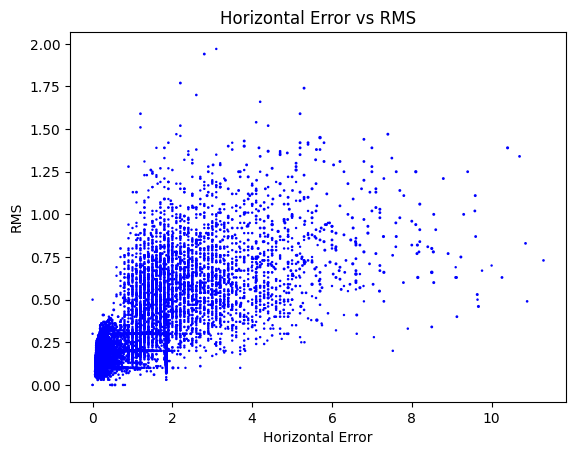

In [24]:
# Scatter plot for horizontal error vs RMS with dots scaled to magnitude
plt.scatter(x=df['horizontalError'], y=df['rms'], s=df['mag'], c='Blue', linewidths=0)

# Labels and title
plt.title('Horizontal Error vs RMS')
plt.xlabel('Horizontal Error')
plt.ylabel('RMS')

# Display plot
plt.show()

## Seasonal Effect on Earthquake Magnitude

For this portion of the data exploration, I will analyze whether the season of the year affects the mean magnitude of earthquakes.

### Hypothesis:
Null Hypothesis (Ho): The season of the year does not have an effect on the magnitude mean of an earthquake.

Alternative Hypothesis (Ha): The season of the year does have an effect on the magnitude mean of an earthquake.

In [25]:
# To map the seasons into a new column for easier analysis
seasons = {
    1: "Winter",
    2: "Winter",
    3: "Spring",
    4: "Spring",
    5: "Spring",
    6: "Summer",
    7: "Summer",
    8: "Summer",
    9: "Fall",
    10: "Fall",
    11: "Fall",
    12: "Winter"
}

# To create the season column
df["season"] = df["month"].map(seasons)

# To separate the seasons and retrieve the magnitudes
winter = df[df["season"] == "Winter"]["mag"]
spring = df[df["season"] == "Spring"]["mag"]
summer = df[df["season"] == "Summer"]["mag"]
fall   = df[df["season"] == "Fall"]["mag"]

# I will use One-Way ANOVA for this test since we are comparing the magnitude means of the seasons
anova = stats.f_oneway(winter, spring, summer, fall)
p_value = anova.pvalue

print(f"The p value: {str(p_value)}")

# This is to determine whether to reject or fail to reject the null hypothesis
# The signifiance level will be at 0.05 default
a = 0.05
if p_value <= a:
  print("Reject the null hypothesis")
else:
  print("Fail to reject the null hypothesis")

The p value: 0.02786919910540275
Reject the null hypothesis


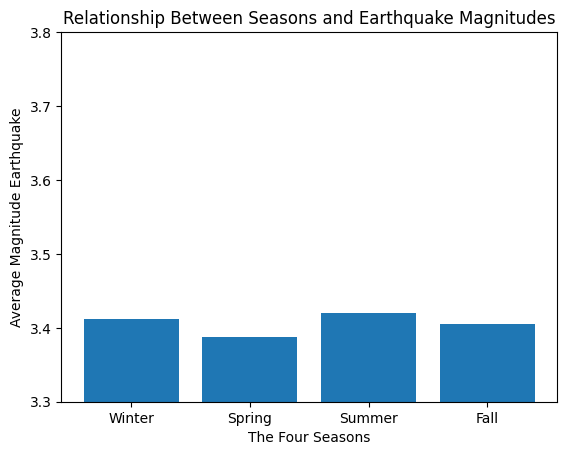

Winter Mean: 3.4113420889705766
Spring Mean: 3.3874941121397426
Summer Mean: 3.4200658925210927
Fall Mean: 3.4046235003585528


In [26]:
# To create a bar graph that has the seasons magnitudes for earthquakes
plt.bar(["Winter", "Spring", "Summer", "Fall"], [winter.mean(), spring.mean(), summer.mean(), fall.mean()])

# To add labels
plt.xlabel("The Four Seasons")
plt.ylabel("Average Magnitude Earthquake")
plt.ylim(3.3, 3.8)
plt.title("Relationship Between Seasons and Earthquake Magnitudes")

# Display plot
plt.show()

# To retrieve the exact values
print(f"Winter Mean: {winter.mean()}")
print(f"Spring Mean: {spring.mean()}")
print(f"Summer Mean: {summer.mean()}")
print(f"Fall Mean: {fall.mean()}")

Observations: Based on the hypothesis, we must reject the null hypothesis because the p-value is less than the significance level (α = 0.05). That means there's evidence in the dataset that the earthquake magnitude differs across seasons, as indicated by the one-way ANOVA. From the graph, we can see that the magnitude of earthquakes is higher during the summer, while spring earthquakes usually have a lower magnitude. The higher earthquake magnitudes in the summer can likely stem from environmental changes, but the averages across seasons mainly remain around 3.3 to 3.4.

### Post Hoc Test

In [27]:
# To run a Tukey's HSD Post Hoc Test since we are looking for the specific
# pairwise group that differs from the ANOVA test
tukey_hsd_result = stats.tukey_hsd(winter, spring, summer, fall)

print(tukey_hsd_result)

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)      0.024     0.192    -0.007     0.055
 (0 - 2)     -0.009     0.865    -0.038     0.020
 (0 - 3)      0.007     0.947    -0.025     0.038
 (1 - 0)     -0.024     0.192    -0.055     0.007
 (1 - 2)     -0.033     0.016    -0.061    -0.004
 (1 - 3)     -0.017     0.487    -0.048     0.014
 (2 - 0)      0.009     0.865    -0.020     0.038
 (2 - 1)      0.033     0.016     0.004     0.061
 (2 - 3)      0.015     0.522    -0.014     0.045
 (3 - 0)     -0.007     0.947    -0.038     0.025
 (3 - 1)      0.017     0.487    -0.014     0.048
 (3 - 2)     -0.015     0.522    -0.045     0.014



Observation: Based on the Post Hoc test, you can see that Spring and Summer (1-2) did differ significantly, with p = 0.016, which is less than the significance level a = 0.05. This is likely due to the Summer season having a higher average earthquake magnitude than the Spring season. The remaining p-values are not significant because they exceed the significance level.

## Distribution and Outlier Analysis of Earthquake Magnitude

Here, I am examining how earthquake magnitudes are distributed and whether there are any unusually large or small values that stand out from the rest of the dataset.

### Method:
To study this, I will use summary statistics along with a histogram and a box plot of earthquake magnitude. This helps show the center, spread, and overall shape of the data, while also making it easier to notice possible outliers.

In [28]:
df["mag"].describe()

count    10931.000000
mean         3.406976
std          0.425872
min          3.000000
25%          3.100000
50%          3.300000
75%          3.570000
max          6.700000
Name: mag, dtype: float64

The summary statistics indicates that the vast majority of seismic activity occurs in a much less severe range when compared to the complete magnitude range of seismic activity. As a result, it can be concluded that there are very many earthquakes of moderate magnitude; however, there are also large and very large magnitude earthquakes that further extend the upward limit of the data set.

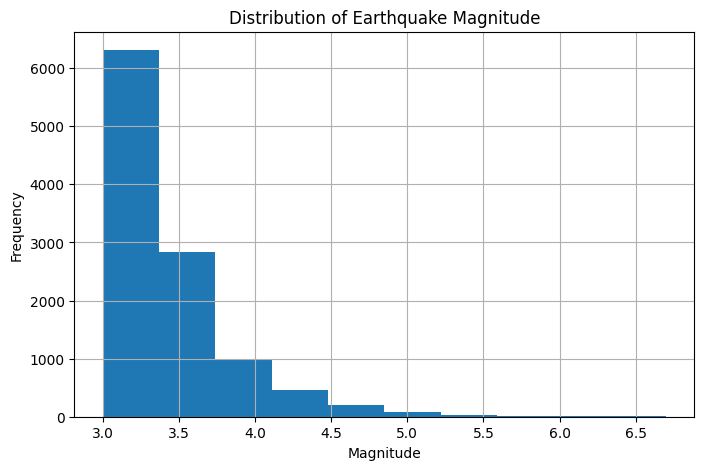

In [29]:
plt.figure(figsize=(8, 5))
df["mag"].hist()
plt.title("Distribution of Earthquake Magnitude")
plt.xlabel("Magnitude")
plt.ylabel("Frequency")
plt.show()

According to the histogram, the distribution of earthquakes by magnitude shows a higher concentration of earthquakes at lower and medium magnitudes than there are at higher magnitudes. As you increase your magnitude, you will decrease how often you will see that magnitude. Therefore, there are generally less frequent large earthquakes in the data set compared to smaller earthquakes.

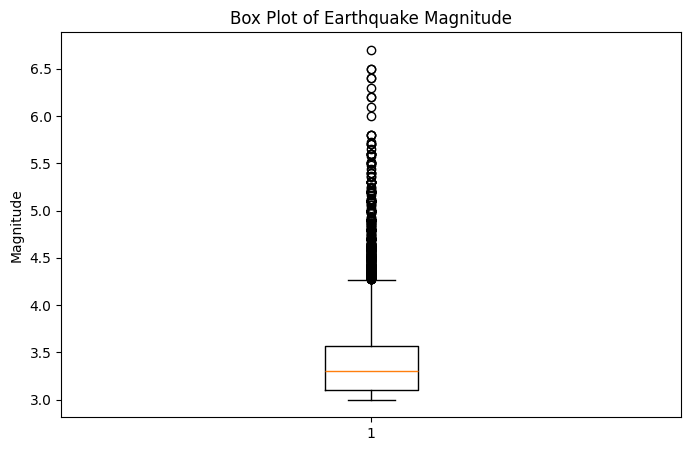

In [30]:
plt.figure(figsize=(8, 5))
plt.boxplot(df["mag"].dropna())
plt.title("Box Plot of Earthquake Magnitude")
plt.ylabel("Magnitude")
plt.show()

The box plot indicates that a significant portion of the data's magnitude is concentrated within the center of the box, and the remaining values have a smaller quantity of values that are much greater than the values adjacent to them. The points located outside of the upper whiskers of the box plot show that their values are greater than the majority of the other Earthquake magnitude values, this indicates that there are some high magnitude earthquakes that are very different from the majority of the data values, supporting the idea that there are outliers in the dataset at the upper end of the magnitude values.

## Conclusion 

The distribution of the earthquake data indicates that most of the earthquakes in the dataset occurred within a much smaller range of magnitudes than those of the few that are clearly outside this scale. The greater the magnitude of an earthquake, the lower the occurrences.

The results of this distribution will be useful for understanding the general structure of one of the variable's primary characteristics within the dataset. Additionally, this example illustrates that extreme variations can often be found in other characteristics associated with both magnitude averages as well as variability, thus presenting a potential barrier when doing later analysis. 

## 5. Primary Analysis – Machine Learning

We framed this as a binary classification problem: predict whether an event is significant (M ≥ 4.5) or minor. We trained four classifiers on an 80/20 stratified train-test split:

- Logistic Regression (baseline)
- Decision Tree
- Random Forest (primary model)
- K-Nearest Neighbors

Features used: latitude, longitude, depth, year, month, hour, dayofweek.

Random Forest performed best. Latitude and longitude were the most important features, confirming that geography is the strongest predictor of earthquake significance.

# Machine Learning Analysis

In [31]:
# The code needed for the machine learning test and analysis
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, silhouette_score

import matplotlib.pyplot as plt
import matplotlib
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize

from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

import ast
pd.set_option('display.max_columns', None)
from scipy.spatial.distance import cdist

import matplotlib.pyplot as plt
import seaborn as sns
import warnings # To suppress some warnings
import plotly.graph_objects as go
import plotly.express as px

# Suppress the specific FutureWarning
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

# To test which ML Model would be useful for our dataset
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [32]:
# Preprocessing to check if any missing data still exists
missing_data = df.isnull().sum().to_dict()

for col, total in missing_data.items():
  print(f"Column: {col}, Missing: {total}")

Column: time, Missing: 0
Column: latitude, Missing: 0
Column: longitude, Missing: 0
Column: depth, Missing: 0
Column: mag, Missing: 0
Column: magType, Missing: 0
Column: nst, Missing: 0
Column: gap, Missing: 0
Column: dmin, Missing: 0
Column: rms, Missing: 0
Column: net, Missing: 0
Column: id, Missing: 0
Column: updated, Missing: 0
Column: place, Missing: 0
Column: type, Missing: 0
Column: horizontalError, Missing: 0
Column: depthError, Missing: 0
Column: magError, Missing: 0
Column: magNst, Missing: 0
Column: status, Missing: 0
Column: locationSource, Missing: 0
Column: magSource, Missing: 0
Column: year, Missing: 0
Column: month, Missing: 0
Column: day, Missing: 0
Column: hour, Missing: 0
Column: dayofweek, Missing: 0
Column: season, Missing: 0


Our goal is to use binary classification to predict whether an earthquake can be significant (Magnitude >= 4.5) or less significant (Magnitude < 4.5). We chose 4.5 because it represents the range between potentially damaging earthquakes and less destructive ones.

In [33]:
# To prepare the data needed for train test split

# Input Data
X = df[["latitude", "longitude", "depth", "year", "month", "hour", "dayofweek"]]

# Binary Classificaiton Label
Y = (df["mag"] >= 4.5).astype(int)

print(X.head())
print(Y.head())

    latitude   longitude    depth  year  month  hour  dayofweek
0  40.547000 -120.700833   6.7800  2025     12     0          0
1  37.943833 -118.679667  14.0100  2025     12    19          6
2  37.663333  -84.457500   6.8500  2025     12    17          6
3  39.160600 -119.047400   5.0000  2025     12    15          5
4  31.964000 -103.122000   8.8135  2025     12     1          5
0    1
1    0
2    0
3    0
4    0
Name: mag, dtype: int64


For train_test_split, we will split the training set to 80% and the test set to 20%. Stratification will be used for this test because significant earthquakes are rarer than less significant ones. By stratifying the Y label, both the training and test cases will be in the same ratio as the full dataset.

In [34]:
# To use train test split for 80/20

seed = 42 # for the random_state
test_size=0.2

# Split your training data
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=test_size, stratify=Y,
                                                    random_state=seed)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(8744, 7)
(2187, 7)
(8744,)
(2187,)


In [35]:
# Normalize the training and test sets using StandardScaler
# To create the standard scaler for X
scaler_X = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

We will use StandardScaler because the data needs to be normalized to a consistent scale during training. If the data is not normalized, the model struggles to converge during training, leading to an imbalance in one of the features. In addition, this will help the model find optimal solutions.

In [36]:
# Create the models dictionary to run on each model
models = {
"KNN": KNeighborsClassifier(),
"DecisionTree": DecisionTreeClassifier(random_state=seed),
"LogisticRegression": LogisticRegression(max_iter=1000, random_state=seed),
"RandomForest": RandomForestClassifier(random_state=seed)
}

In [37]:
# Perform k-fold Cross-Validation for each model
k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=seed)

for model_name, model in models.items():
    np.random.seed(seed)
    print(f"Model: {model_name}")

    # Perform k folds cross validation to get cross validation accuracy to determine most accurate ML model
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=skf, scoring="accuracy")
    print(f"Cross-validated Accuracy: { cv_scores.mean() } (+/- { cv_scores.std()})")


Model: KNN
Cross-validated Accuracy: 0.9694651929248881 (+/- 0.0018234676107824921)
Model: DecisionTree
Cross-validated Accuracy: 0.9459065853910635 (+/- 0.005010740239343887)
Model: LogisticRegression
Cross-validated Accuracy: 0.9703797397139654 (+/- 0.00022202945651845772)
Model: RandomForest
Cross-validated Accuracy: 0.970380132223317 (+/- 0.0022062704694832984)


Based on the provided cross-validated accuracy results for each model, all the results range from 96% to 97%. Although these scores are high, we need to evaluate the models further using recall and precision to determine whether Random Forest is the right model for our dataset, since it is the highest score.

In [38]:
# Train the model and retrieve the clssification report

# Train each model using the training data
for model_name, model in models.items():
    # Set random seed for reproducibility
    np.random.seed(seed)
    model.fit(X_train_scaled, y_train)

# Evaluate the performance of each model
for model_name, model in models.items():
    np.random.seed(seed)

    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy of {model_name}: {accuracy:.3f}") # Your accuracy table header here
    print(classification_report(y_test, y_pred, target_names=['Minor (False)', 'Major (True)'], zero_division=0))

Accuracy of KNN: 0.971
               precision    recall  f1-score   support

Minor (False)       0.97      1.00      0.99      2122
 Major (True)       0.53      0.14      0.22        65

     accuracy                           0.97      2187
    macro avg       0.75      0.57      0.60      2187
 weighted avg       0.96      0.97      0.96      2187

Accuracy of DecisionTree: 0.949
               precision    recall  f1-score   support

Minor (False)       0.98      0.97      0.97      2122
 Major (True)       0.18      0.20      0.19        65

     accuracy                           0.95      2187
    macro avg       0.58      0.59      0.58      2187
 weighted avg       0.95      0.95      0.95      2187

Accuracy of LogisticRegression: 0.970
               precision    recall  f1-score   support

Minor (False)       0.97      1.00      0.98      2122
 Major (True)       0.00      0.00      0.00        65

     accuracy                           0.97      2187
    macro avg      

In our classification report, you can see that Random Forest has the highest classification accuracy score of around 97.2%, followed by KNN at around 97.1%, Logistic Regression at around 97%, and Decision Tree at around 94.9%. Specifically, the Random Forest model achieved a precision of around 59% in detecting significant earthquakes. However, the recall is around 15%, lower than the Decision Tree's recall rate of around 20%. This is due to the rarity of significant earthquakes, which causes a bias towards smaller-magnitude earthquakes. Despite this, Random Forest remains a good option for accuracy and precision, but struggles with recall for significant earthquakes. The low recall remains a difficult problem even with large datasets.

In [39]:
# Extract the feature importances from the most accurate model
importances = models["RandomForest"].feature_importances_

# DataFrame to display feature importances
feature_importance_df = pd.DataFrame({"feature": X_train.columns,
                                      "importances": importances}).sort_values(by="importances", ascending=False)

# Displaying feature importances
print("Feature Importances:")
print(feature_importance_df)

Feature Importances:
     feature  importances
0   latitude     0.292835
1  longitude     0.235684
2      depth     0.174063
5       hour     0.107284
4      month     0.068896
6  dayofweek     0.063664
3       year     0.057575


Based on the feature importance chart, you can see that latitude, longitude, and depth are the most important predictors of significant earthquakes with high magnitude. This makes sense, since the events can occur based on the distance from active tectonic activity. In addition, the distance near plate boundaries, such as around the Ring of Fire, will experience stronger magnitude earthquakes. The time being the least important also aligns with our findings, which show little relationship in magnitude. 

# 6. Visualization

## Earthquake Map

Using GeoPandas, we can visualize where the U.S.G.S. earthquakes in the dataset were located in the contiguous United States; Hawaii and Alaska are excluded because no datapoints are there. Lighter colors indicate that the earthquakes have a larger magnitude.

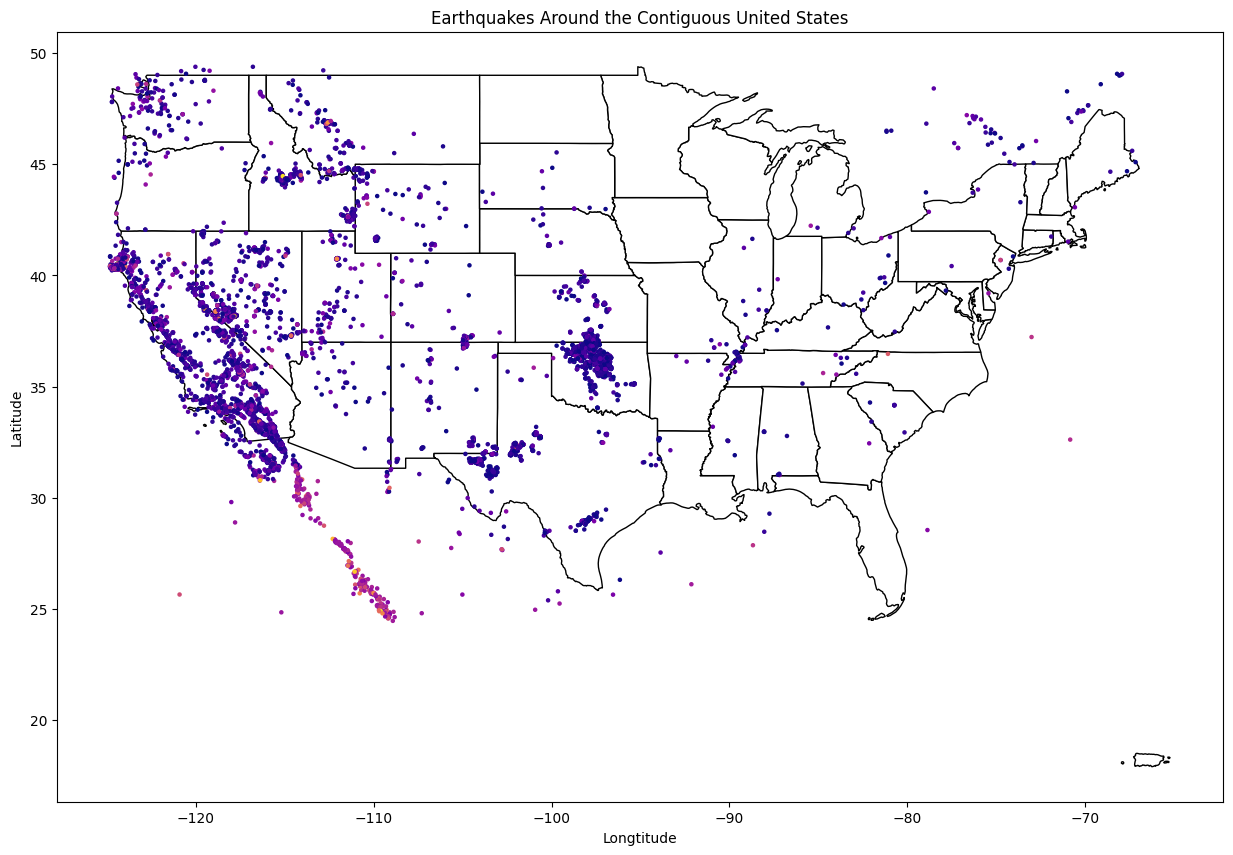

In [91]:
import geopandas as gpd

geometry = gpd.points_from_xy(df["longitude"], df["latitude"])
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs=4326)

usa = gpd.read_file("visuals/cb_2018_us_state_20m.shp")
cropped_usa = usa.clip([-130, -50, 30, 55])

fig, ax = plt.subplots(figsize=(20, 10))

cropped_usa.plot(ax=ax, color='white', edgecolor='black')
gdf.plot(ax=ax, marker='o', markersize=5, column=df['mag'], cmap='plasma')

ax.set_title("Earthquakes Around the Contiguous United States")
ax.set_xlabel("Longtitude")
ax.set_ylabel("Latitude")

plt.show()

From the map, we can see that a lot of earthquakes tend to cluster around California and the Pacific Northwest, which makes sense given these regions' aforementioned proximity to the Ring of Fire. Earthquakes on the Mexican coast also fit this pattern. However, there are also clusters around Oklahoma and Texas, states not well known for seismic activity. Doing some research into this reveals that earthquakes in Oklahoma and Texas are likely primarily caused by reinjecting wastewater from oil and gas operations. Finally, there are some earthquakes in the Midwest roughly where the New Madrid fault is located.

## Features vs Magnitude

Primary analysis found that latitude, longitude, and depth are the three most important features for predicting earthquake magnitude. Thus, attached below are three scatter plots with linear regression done to illustrate the relationships between these three features and magnitude.

Text(0.5, 1.0, 'Latitude vs Magnitude')

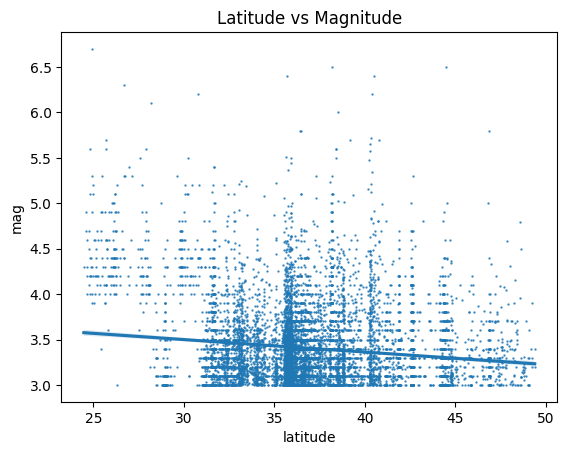

In [71]:
# Using Seaborn here since it is much more concise
sns.regplot(data=df, x="latitude", y="mag", scatter=True, scatter_kws={"s": 0.5})
plt.title("Latitude vs Magnitude")

A more northern latitude seems to be slightly corelated with lower magnitude earthquakes. This fits with the above map, which shows that many larger earthquakes happen at more southern latitudes.

Text(0.5, 1.0, 'Longitude vs Magnitude')

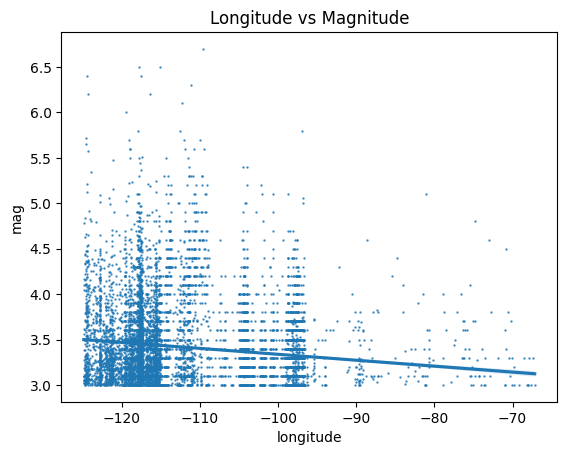

In [72]:
sns.regplot(data=df, x="longitude", y="mag", scatter=True, scatter_kws={"s": 0.5})
plt.title("Longitude vs Magnitude")

Further east longitudes seem to be somewhat associated with smaller magnitudes of earthquakes, which can be attributed to significantly higher natural seismic activity on the Ring of Fire. For reference, a longitude of -90 is roughly in the Midwest.

Text(0.5, 1.0, 'Depth vs Magnitude')

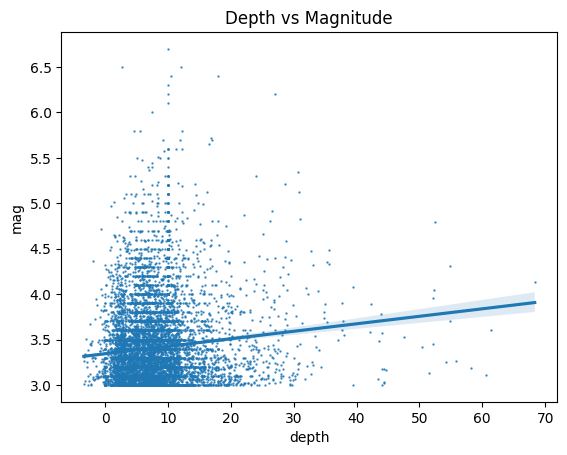

In [73]:
sns.regplot(data=df, x="depth", y="mag", scatter=True, scatter_kws={"s": 0.5})
plt.title("Depth vs Magnitude")

Although the regression line appears to show higher depth is roughly associated with higher magnitude, the dataset contains many more shallow earthquakes. As expected, it is the weakest predictor of magnitude among the three features selected.

## Earthquake Magnitude KDE

Exploratory data analysis used a histogram to display the distribution of magnitudes; now, we use a KDE to more accurately show the distribution.

Text(0.5, 1.0, 'Distribution of Magnitude')

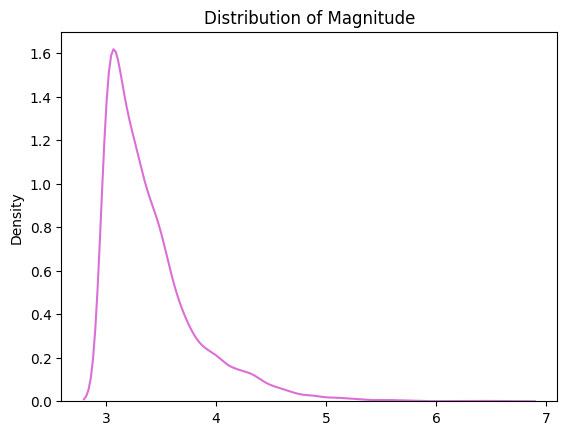

In [96]:
sns.kdeplot(data=df["mag"].to_numpy(), color="orchid")
plt.title("Distribution of Magnitude")

Similar to the earlier plot, the KDE shows small and medium magnitude earthquakes are far more common than new ones. We have already seen above how this complicates using factors such as latitude, longitude, and depth as predictors, leading to relatively even feature importances since the top features have relatively little predictive power.

## 7. Insights and Conclusions

The overall conclusion from this project is that most earthquakes in our dataset were small or moderate events. Most earthquakes were closer to the lower end of the magnitude range, especially between magnitude 3.0 and 4.5, rather than being evenly spread across the full range. Larger earthquakes were much less common, which makes sense because major earthquakes occur less frequently than smaller seismic events. The histogram, KDE plot, and box plot helped show this pattern clearly by showing that high-magnitude earthquakes appear more like outliers compared to the rest of the data.

The correlation analysis showed that earthquake magnitude is not strongly explained by one simple feature. Depth had a weak positive correlation with magnitude, meaning deeper earthquakes tended to be slightly larger, but the relationship was still weak. Some measurement-related features had stronger relationships with each other than they did with magnitude. For example, horizontal error, depth error, and RMS were more closely related to each other. This suggests that some of the strongest relationships in the dataset are connected to measurement error rather than the physical strength of the earthquake itself.

We also investigated whether earthquake severity changed by season. To do this, we used an ANOVA test. The results showed a statistically significant difference in average earthquake magnitude by season, with a p-value below 0.05. However, the actual average magnitudes across seasons were very close to each other. Summer had the highest average magnitude, while spring had the lowest, but the difference was small. Because of this, season may have a statistical relationship with earthquake magnitude, but it does not seem strong enough to be a major explanation by itself.

For the machine learning section, we used binary classification to predict whether an earthquake would be classified as significant based on a magnitude cutoff of 4.5 or higher. The models had high overall accuracy, with the Random Forest model performing the best at about 97.2% accuracy. However, accuracy alone was misleading because there were very few significant earthquakes in the dataset. Since most earthquakes were not significant, a model could get a high accuracy score by mostly predicting the majority class.

Out of the models we used, the Random Forest model performed the best overall. It had strong accuracy and was the most reliable model when predicting significant earthquake events. However, it still struggled with recall, meaning it missed many earthquakes that were actually significant. This shows one of the main challenges of the project: even when a model performs well overall, it can still have trouble identifying rare events.

The biggest obstacle in this project was class imbalance. There were many more non-significant earthquakes than significant ones. This made it harder for the models to learn how to correctly identify larger earthquake events. The Random Forest feature importance results also showed that location was the most important factor in prediction. Latitude and longitude were the strongest predictors, followed by depth. This suggests that where an earthquake happens is more useful for prediction than time-based features such as year, month, hour, or day of the week. This result makes sense because earthquake activity is strongly connected to location, which may reflect underlying geological structure.

One important limitation of this project is that the dataset only includes earthquakes in the contiguous United States with a magnitude of 3.0 or higher. Because of that, the results do not represent every earthquake, especially smaller earthquakes or earthquakes outside this region. Another limitation is that the model only used features available in the USGS dataset. It did not include information such as fault lines, plate boundaries, rock type, soil type, or distance from known seismic zones. Adding those features could likely make the model stronger.

In conclusion, this project gave us a better understanding of earthquake patterns in the United States. Most events in the dataset were lower-magnitude earthquakes, seasonal differences existed but were small, and geographic location was the strongest predictor of whether an earthquake would be significant. The machine learning results showed that identifying rare significant earthquakes is challenging because of class imbalance. Even though this project is not meant to predict future earthquakes before they happen, it shows how data science can be used to study seismic activity and find patterns in natural hazard data.

CMSC 320 · Spring 2026 · University of Maryland | Data: USGS ANSS ComCat